In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from numpy import loadtxt
from sklearn.metrics import accuracy_score, f1_score
import pickle

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


In [3]:
data = pd.read_csv('Train_Loan.csv') 

In [4]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


(614, 13)

In [6]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
data[numerical_cols] = data[numerical_cols].apply(pd.to_numeric, errors='coerce')  
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].mean())  



In [7]:
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status','Dependents']
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])  


In [8]:
label_encoder = LabelEncoder()

In [9]:
data['Gender'] = label_encoder.fit_transform(data['Gender'])  
data['Married'] = label_encoder.fit_transform(data['Married'])  
data['Education'] = label_encoder.fit_transform(data['Education'])  
data['Self_Employed'] = label_encoder.fit_transform(data['Self_Employed'])  
data['Property_Area'] = label_encoder.fit_transform(data['Property_Area'])  
data['Loan_Status'] = label_encoder.fit_transform(data['Loan_Status'])  



In [10]:
data = data.drop(['Loan_ID','Dependents'], axis=1)


In [11]:
data.isnull().sum()  

Gender               0
Married              0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [12]:
for col in data.columns:
    if data[col].dtypes == 'object':
        num_of_unique_cat = len (data[col].unique())
        print("Features '{col_name}' has '{unique_cat}' unique categories". format(col_name=col, unique_cat=num_of_unique_cat))

In [13]:
data['Self_Employed'].replace({'Yes':1,'No':0},inplace=True)
data['Married'].replace({'Yes':1,'No':0},inplace=True)
data['Gender'].replace({'Male':1,'Female':0},inplace=True)
data['Education'].replace({'Graduate':1,'Not Graduate':0},inplace=True)
data['Property_Area'].replace({'Urban':2,'Semiurban':1,'Rural':0},inplace=True)
data['Loan_Status'].replace({'Y':1,'N':0},inplace=True)

In [14]:
y = data['Loan_Status'] 
X = data.drop('Loan_Status', axis = 1) 

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)


In [16]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
X_test_resampled, y_test_resampled = smote.fit_resample(X_test, y_test)

In [17]:

ann_model = Sequential()
ann_model.add(Dense(units=64, activation='relu', input_dim=X_train_resampled.shape[1]))
ann_model.add(Dense(units=128, activation='relu'))
ann_model.add(Dropout(0.2))
ann_model.add(Dense(units=256, activation='relu'))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(units=128, activation='relu'))
ann_model.add(Dropout(0.2))
ann_model.add(Dense(units=1, activation='sigmoid'))  
ann_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
history=ann_model.fit(X_train_resampled, y_train_resampled, epochs=25, batch_size=32, validation_split=0.2, verbose=1)

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.6081 - loss: 0.6659 - val_accuracy: 0.4380 - val_loss: 0.7760
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7530 - loss: 0.5556 - val_accuracy: 0.4453 - val_loss: 0.8112
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7634 - loss: 0.5215 - val_accuracy: 0.4964 - val_loss: 0.6227
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7521 - loss: 0.5098 - val_accuracy: 0.5109 - val_loss: 0.6688
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7679 - loss: 0.4810 - val_accuracy: 0.5328 - val_loss: 0.6522
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7712 - loss: 0.4799 - val_accuracy: 0.5255 - val_loss: 0.7113
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8029 - loss: 0.4560 - val_accuracy: 0.5912 - val_loss: 0.5644
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8003 - loss: 0.4330 - val_accuracy: 0.5985 - 

In [39]:
ypred_ann = ann_model.predict(X_test)
ypred_ann = (ypred_ann > 0.5).astype(int)  

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

f1 = f1_score(y_test, ypred_ann)
model_ann = ann_model.predict(X_train_resampled)
model_ann = (model_ann > 0.5).astype(int) 

model_ann_acc = accuracy_score(y_train_resampled, model_ann)

print('Accuracy: ',model_ann_acc)
print(f"F1 Score: {f1}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Accuracy:  0.8698830409356725
F1 Score: 0.8114285714285715


In [38]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

import xgboost as xgb

model_xgb = xgb.XGBClassifier(
    learning_rate=0.95, 
    n_estimators=5,  
    max_depth=3,  
    subsample=0.4,  
    colsample_bytree=0.4,  
    min_child_weight=50,  
    random_state=42
)
model_xgb.fit(X_train, y_train) 
ypred = model_xgb.predict(X_test) 
evaluation_xg = f1_score(y_test, ypred)
evaluation_xg


0.7881773399014779

In [20]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(
    learning_rate=0.5, 
    num_leaves=10, 
    max_depth=50,
    n_estimators=10,
    min_data_in_leaf=1000
)
model_lgbm.fit(X_train, y_train) 
ypred = model_lgbm.predict(X_test) 
evaluation_lg = f1_score(y_test, ypred)
evaluation_lg    

[LightGBM] [Warning] min_data_in_leaf is set=1000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1000
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Warning] min_data_in_leaf is set=1000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1000
[LightGBM] [Info] Number of positive: 342, number of negative: 149
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 0
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.696538 -> initscore=0.830864
[LightGBM] [Info] Start training from score 0.830864
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[L

0.7881773399014779

In [21]:
from sklearn.tree import DecisionTreeClassifier

model_dtc = DecisionTreeClassifier()
model_dtc.fit(X_train, y_train) 
ypred = model_dtc.predict(X_test) 
evaluation_dt = f1_score(y_test, ypred)
evaluation_dt

0.7682926829268292

In [37]:
from sklearn.ensemble import RandomForestClassifier

model_rfc = RandomForestClassifier(
    n_estimators=5,  
    max_depth=100, 
    min_samples_split=1000,  
    random_state=42
)

model_rfc.fit(X_train, y_train)
ypred = model_rfc.predict(X_test) 
evaluation_rf = f1_score(y_test, ypred)
evaluation_rf

0.7881773399014779

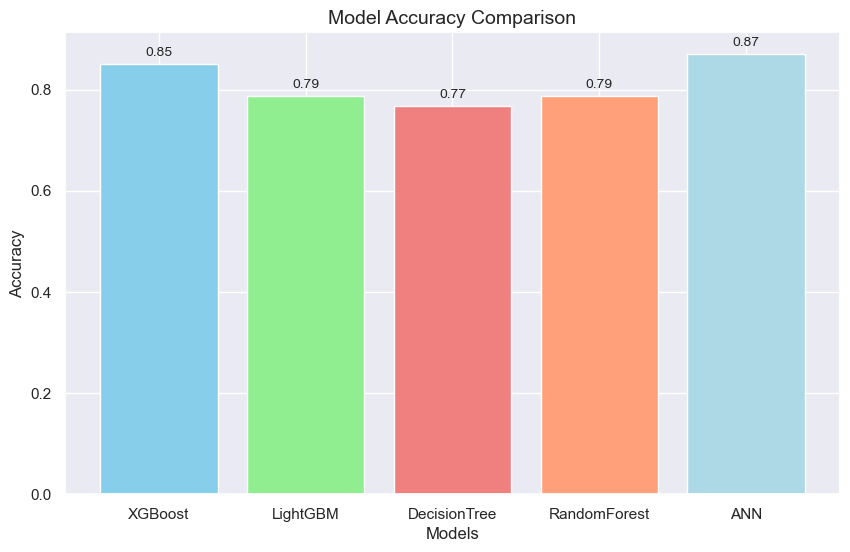

In [23]:
import matplotlib.pyplot as plt

accuracies = [evaluation_xg, evaluation_lg, evaluation_dt, evaluation_rf, model_ann_acc]  
model_names = ['XGBoost', 'LightGBM', 'DecisionTree', 'RandomForest', 'ANN']

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'lightblue'])

plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=10)

plt.show()


In [36]:
pickle.dump(ann_model,open('model.pkl','wb'))